In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPORT_PATH = "/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260727-single-internaltx-deepsad-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_xchainwatcher_testsplitinvalid_epochs100_augment0_lr0.005_nosf_es15_202607272010/inference_deepsad-xchainwatcher_202607272012/infer_report.csv"

COLOR_NORMAL = "#2a78d6"   # blue
COLOR_ANOMALY = "#e9a718"  # orange

In [2]:
def load_scores(csv_path: str) -> tuple[pd.DataFrame, list[int]]:
    df = pd.read_csv(csv_path)
    fold_numbers = sorted(
        int(c.split("_")[1]) for c in df.columns if c.endswith("_score")
    )
    return df, fold_numbers

df, fold_numbers = load_scores(REPORT_PATH)
fold_numbers


[1, 2, 3, 4, 5]

In [3]:
def plot_fold_distributions(df: pd.DataFrame, fold_numbers: list[int], bins: int = 40, x_max: float = None) -> plt.Figure:
    ncols = 3
    nrows = -(-len(fold_numbers) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for i, fold in enumerate(fold_numbers):
        ax = axes_flat[i]
        score_col = f"fold_{fold}_score"
        normal_scores = df.loc[df["true_label"] == 0, score_col]
        anomaly_scores = df.loc[df["true_label"] == 1, score_col]

        lo = 0.0
        hi = x_max if x_max is not None else df[score_col].max()

        if x_max is not None:
            normal_scores = normal_scores[normal_scores <= x_max]
            anomaly_scores = anomaly_scores[anomaly_scores <= x_max]

        bin_edges = np.linspace(lo, hi, bins + 1)

        ax.hist(
            normal_scores, bins=bin_edges, density=True,
            histtype="stepfilled", color=COLOR_NORMAL, alpha=0.55,
            edgecolor=COLOR_NORMAL, linewidth=1.2, label="Normal",
        )
        ax.hist(
            anomaly_scores, bins=bin_edges, density=True,
            histtype="stepfilled", color=COLOR_ANOMALY, alpha=0.55,
            edgecolor=COLOR_ANOMALY, linewidth=1.2, label="Anomaly",
        )

        ax.set_title(f"Fold {fold}")
        ax.set_xlabel("Anomaly score")
        ax.set_ylabel("Density")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    for j in range(len(fold_numbers), len(axes_flat)):
        axes_flat[j].set_visible(False)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Score distribution: normal vs. anomaly, per fold", y=1.05)
    fig.tight_layout()
    return fig


/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


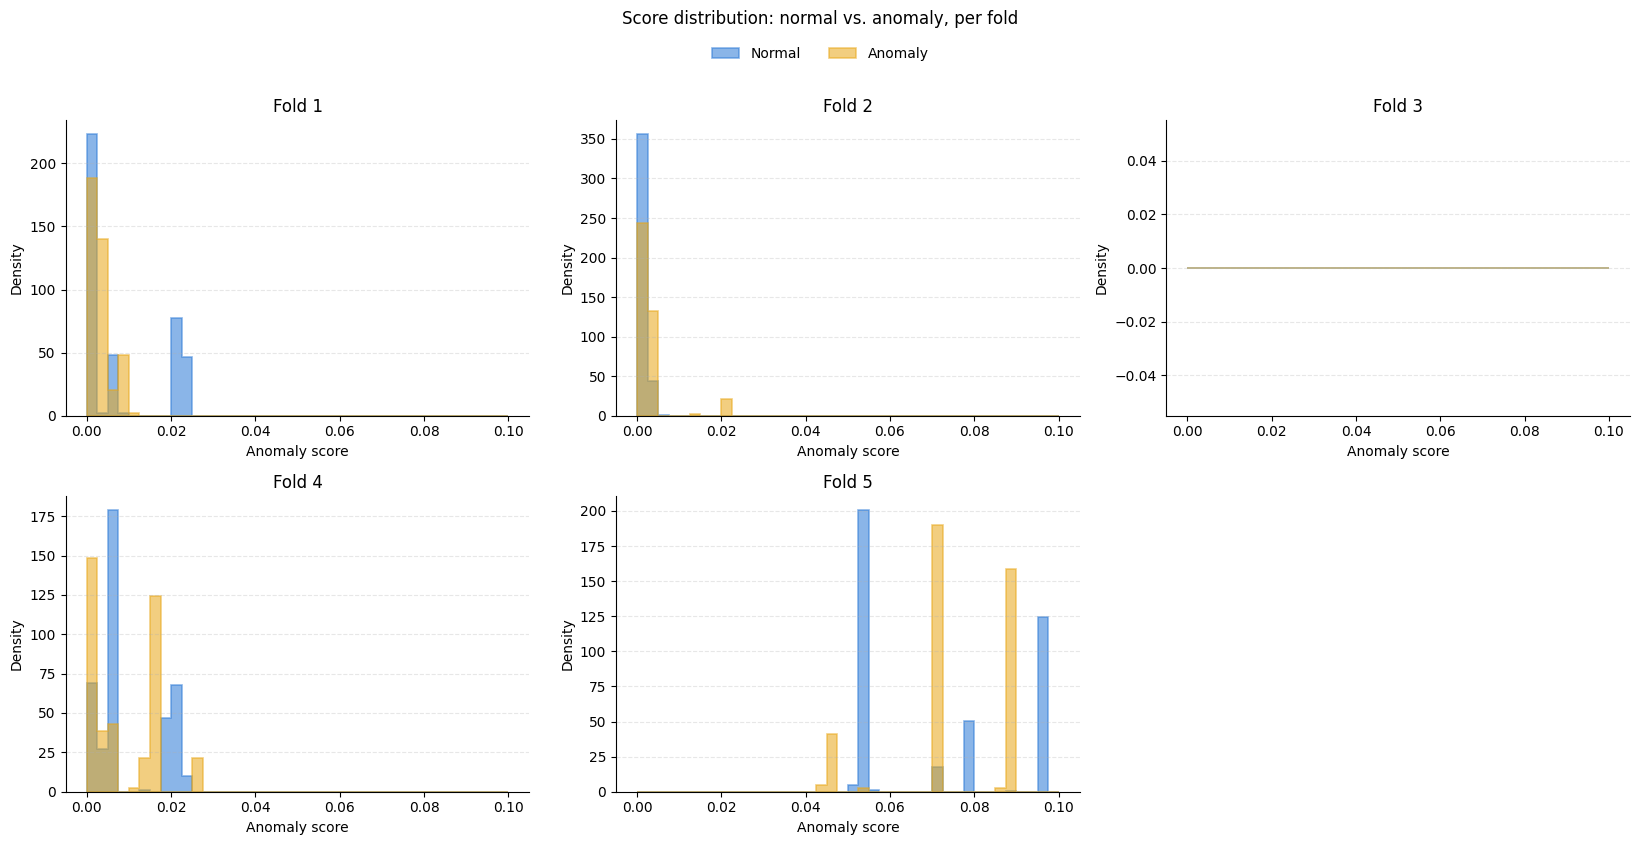

In [5]:
fig = plot_fold_distributions(df, fold_numbers, x_max=0.1)
plt.show()